In [2]:
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
import numpy as np
from sklearn.manifold import TSNE
import seaborn as sns
from gensim.models.doc2vec import Doc2Vec
import matplotlib.pyplot as plt


In [37]:
from Classes import Word2VecTransform

ModuleNotFoundError: No module named 'Classes'

In [32]:
model = Doc2Vec.load('Doc2Vec_1.0')


In [36]:
vector = model.infer_vector(["syste998hg",'Gaaggagj'])

In [7]:
wv = KeyedVectors.load("Patent2Vec_1.0", mmap='r')


In [8]:
words = set(wv.wv.index_to_key)


In [5]:
vector = wv.wv['computer']

In [1]:
sims = wv.wv.most_similar('good', topn=10)

NameError: name 'wv' is not defined

In [17]:
sims

[('satisfactory', 0.8098112344741821),
 ('excellent', 0.8082832098007202),
 ('poor', 0.78707355260849),
 ('favorable', 0.7323600053787231),
 ('superior', 0.6439575552940369),
 ('adequate', 0.6320476531982422),
 ('poorer', 0.630235493183136),
 ('bad', 0.62859708070755),
 ('unsatisfactory', 0.6212027072906494),
 ('better', 0.6195934414863586)]

In [20]:
len(wv.wv)

387919

In [24]:
def reduce_dimensions(model):
    num_components = 2  # number of dimensions to keep after compression

    # extract vocabulary from model and vectors in order to associate them in the graph
    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)  

    # apply TSNE 
    tsne = TSNE(n_components=num_components, random_state=0)
    vectors = tsne.fit_transform(vectors)

    x_vals = [v[0] for v in vectors]
    y_vals = [v[1] for v in vectors]
    return x_vals, y_vals, labels

x_vals, y_vals, labels = reduce_dimensions(wv)

In [26]:
from joblib import dump

dump(x_vals,'x_vals')

['x_vals']

In [27]:
dump(y_vals,'y_vals')
dump(labels,'labels')

['labels']

In [1]:
from joblib import load

x_vals = load('x_vals')
y_vals = load('y_vals')
labels = load('labels')

In [3]:
import pandas as pd

x_vals = pd.Series(x_vals)
y_vals = pd.Series(y_vals)
labels = pd.Series(labels)

plot_val = pd.concat([x_vals,y_vals,labels], axis=1)

In [4]:
plot_val

,0,1,2
0,-2.110944,-46.033043,the
1,-2.096767,-46.024315,of
2,-2.156703,-46.083237,a
3,-2.082034,-46.006050,to
4,-2.107537,-46.115108,and
...,...,...,...
387914,-54.684444,8.612457,malhi
387915,11.410974,-9.547964,michemshield
387916,28.702589,46.916630,glyceraldehydephosphates
387917,28.690861,46.929482,xylulosephosphate


In [22]:
for i in plot_val.values:
    print(i[0])

-2.1109440326690674
-2.096766710281372
-2.156702756881714
-2.082033634185791
-2.107537269592285
-2.1046364307403564
-2.427311658859253
-2.334880828857422
-2.4263386726379395
-3.5311026573181152
-2.1297547817230225
-1.9643608331680298
-1.9637935161590576
18.18773651123047
-2.1552131175994873
-10.731148719787598
-1.9693562984466553
-2.0191662311553955
-2.4099042415618896
-4.246711730957031
14.909135818481445
-2.0874316692352295
-2.159008264541626
14.912280082702637
-10.732492446899414
-2.700704336166382
-2.823533058166504
-2.729388475418091
-4.634597301483154
15.211541175842285
-4.068924903869629
-3.299694299697876
-1.5454180240631104
-3.9956305027008057
-4.024420261383057
-2.2724597454071045
13.854523658752441
-2.063337802886963
-29.271337509155273
-2.2864482402801514
15.749958992004395
-9.930413246154785
54.414546966552734
-11.958284378051758
-0.4784417152404785
-0.24491378664970398
-1.2974209785461426
-29.331443786621094
-2.6367573738098145
-2.004653215408325
-4.351472854614258
7.4450

KeyboardInterrupt: 

<Axes: xlabel='0', ylabel='1'>

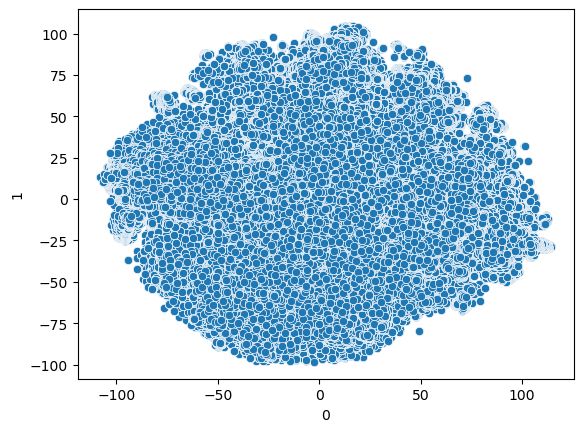

In [5]:
import seaborn as sns

sns.scatterplot(data= plot_val, x=plot_val[0], y=plot_val[1])

In [6]:
fig, ax = plt.subplots()
ax.plot(plot_val[0], plot_val[1], 'o')
ax.set_title('Tweets')
ax.set_yticklabels([]) #Hide ticks
ax.set_xticklabels([]) #Hide ticks

for word in plot_val.values:
	plt.annotate(word[2], xy=(word[0], word[1]))
plt.show()

KeyboardInterrupt: 

In [9]:
keys = ['patent', 'law', 'court', 'appeal', 'invention', 'art', 'judge', 'outcome', 'appellant', 'case']

embedding_clusters = []
word_clusters = []
for word in keys:
    print(f"Key = {word}")
    embeddings = []
    words = []
    for similar_word, _ in wv.wv.most_similar(word, topn=30):
        words.append(similar_word)
        embeddings.append(wv.wv[similar_word])
    embedding_clusters.append(embeddings)
    word_clusters.append(words)

Key = patent
Key = law
Key = court
Key = appeal
Key = invention
Key = art
Key = judge
Key = outcome
Key = appellant
Key = case


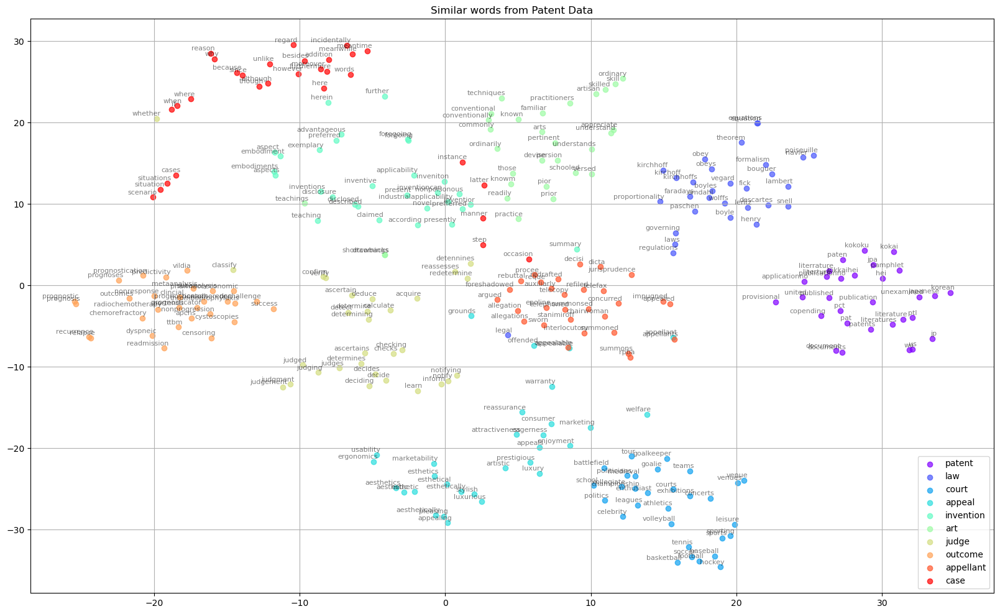

In [11]:
import matplotlib
import matplotlib.cm as cm   


embedding_clusters = np.array(embedding_clusters)
n, m, k = embedding_clusters.shape
tsne_model_en_2d = TSNE(perplexity=15, n_components=2, init='pca', n_iter=3500, random_state=32, n_jobs=-1)
embeddings_en_2d = np.array(tsne_model_en_2d.fit_transform(embedding_clusters.reshape(n * m, k))).reshape(n, m, 2)

def tsne_plot_similar_words(title, labels, embedding_clusters, word_clusters, a, filename=None):
    figsize = (9.5,6) if (matplotlib.get_backend() == 'nbAgg') else (20,12)  # interactive plot should be smaller
    plt.figure(figsize=(figsize))
    colors = cm.rainbow(np.linspace(0, 1, len(labels)))
    for label, embeddings, words, color in zip(labels, embedding_clusters, word_clusters, colors):
        x = embeddings[:, 0]
        y = embeddings[:, 1]
        plt.scatter(x, y, c=[color], alpha=a, label=label)
        for i, word in enumerate(words):
            plt.annotate(word, alpha=0.5, xy=(x[i], y[i]), xytext=(5, 2),
                         textcoords='offset points', ha='right', va='bottom', size=8)
    plt.legend(loc=4)
    plt.title(title)
    plt.grid(True)
    plt.show()


tsne_plot_similar_words('Similar words from Patent Data', keys, embeddings_en_2d, word_clusters, 0.7,
                        'similar_words.png')

In [ ]:
#BECHMARKS https://github.com/kudkudak/word-embeddings-benchmarks